In [1]:
import io
import pandas as pd

# Data lengkap 31 mahasiswa dari file pablo.xlsx
csv_data = """ID,Name,KUIS,UTS,UAS,Nilai,Grade
2455301098,M.Ghiffari Zarnouval,85,81,87,84.38,A
120001,John Doe,85,78,90,84.44,A
120005,Jane Smith,92,88,94,91.38,A
120017,Michael Johnson,48,65,56,56.41,C
120018,Emily Brown,90,85,88,87.65,A
120022,Daniel Martinez,75,80,77,77.35,AB
120024,Sarah Wilson,88,70,65,74.01,B
120025,David Garcia,75,70,75,73.35,B
120027,Jessica Lee,95,91,96,94.03,A
120034,Matthew Davis,79,84,78,80.30,AB
120035,Jennifer Rodriguez,42,48,63,51.33,C
120036,Andrew Taylor,53,64,59,58.73,C
120038,Amanda Hernandez,91,95,90,91.97,A
120039,Christopher Clark,76,81,75,77.30,AB
120046,Elizabeth Martinez,89,93,88,89.97,A
120047,William Anderson,80,85,79,81.30,A
120049,Sophia Thomas,94,90,95,93.03,A
120054,James White,77,82,76,78.30,AB
120060,Olivia Taylor,86,89,84,86.29,A
120063,Benjamin Wilson,92,88,93,91.03,A
120070,Emma Garcia,78,83,77,79.30,AB
120071,Alexander Davis,41,53,44,46.01,F
120073,Mia Moore,68,49,54,56.83,C
120082,Ethan Jackson,81,87,80,82.63,A
120083,Isabella Brown,87,90,85,87.29,A
120088,Noah Taylor,79,84,78,80.30,AB
120090,Abigail Johnson,70,77,64,70.21,B
120093,Logan Martinez,67,54,54,58.16,C
120095,Avery Clark,69,62,71,67.39,B
120098,Jacob Thompson,76,81,75,77.30,AB
120099,Samantha Harris,60,65,64,63.05,BC"""

# Membaca data ke dalam DataFrame
dataraw = pd.read_csv(io.StringIO(csv_data))

# Catatan: Jika ingin membaca langsung dari file Excel pablo.xlsx di Colab:
# dataraw = pd.read_excel('pablo.xlsx')
# dataraw.rename(columns={'Final Score': 'Nilai'}, inplace=True)

print(f"Total baris data: {len(dataraw)} mahasiswa\n")
print(dataraw)


Total baris data: 31 mahasiswa

            ID                  Name  KUIS  UTS  UAS  Nilai Grade
0   2455301098  M.Ghiffari Zarnouval    85   81   87  84.38     A
1       120001              John Doe    85   78   90  84.44     A
2       120005            Jane Smith    92   88   94  91.38     A
3       120017       Michael Johnson    48   65   56  56.41     C
4       120018           Emily Brown    90   85   88  87.65     A
5       120022       Daniel Martinez    75   80   77  77.35    AB
6       120024          Sarah Wilson    88   70   65  74.01     B
7       120025          David Garcia    75   70   75  73.35     B
8       120027           Jessica Lee    95   91   96  94.03     A
9       120034         Matthew Davis    79   84   78  80.30    AB
10      120035    Jennifer Rodriguez    42   48   63  51.33     C
11      120036         Andrew Taylor    53   64   59  58.73     C
12      120038      Amanda Hernandez    91   95   90  91.97     A
13      120039     Christopher Clark    76  

In [2]:
# #Tabel Frekuensi
datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")

# Mengurutkan grade sesuai tingkatan
urutan = ["A", "AB", "B", "BC", "C", "F"]
datafrq = datafrq.reindex([g for g in urutan if g in datafrq.index])

# Menambahkan kolom persentase
datafrq["Persentase (%)"] = (
    (datafrq["Frekuensi"] / datafrq["Frekuensi"].sum()) * 100
).round(2)

print(datafrq)

col_0  Frekuensi  Persentase (%)
Grade                           
A             13           41.94
AB             7           22.58
B              4           12.90
BC             1            3.23
C              5           16.13
F              1            3.23


<Axes: xlabel='Grade'>

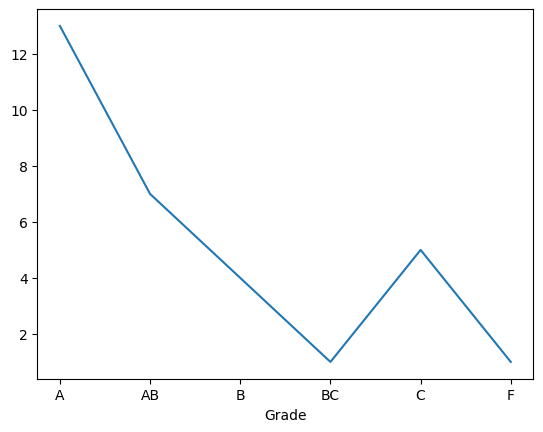

In [3]:
# #Grafik Garis
datafrq["Frekuensi"].plot()

<Axes: xlabel='Grade'>

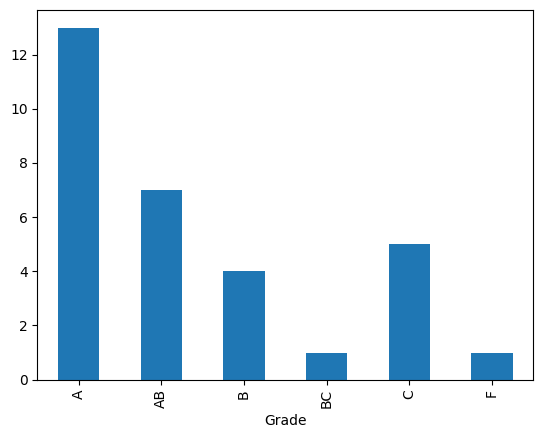

In [4]:
# #Grafik Batang
datafrq["Frekuensi"].plot(kind="bar")

<Axes: ylabel='Frekuensi'>

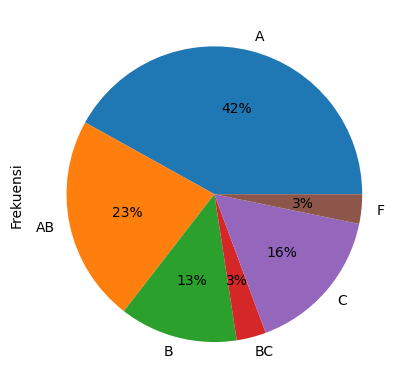

In [5]:
# #Pie Chart
datafrq.plot(kind="pie", y="Frekuensi", autopct="%1.0f%%", legend=False)


In [6]:
# #Statistika Deskriptif
dataraw["Nilai"] = pd.to_numeric(dataraw["Nilai"], errors="coerce")
dt = dataraw["Nilai"]

stats = dt.describe()
stats["Standard Error"] = dt.sem()
stats["Median"] = dt.median()
stats["Mode"] = dt.mode().iloc[0]
stats["variance"] = dt.var()
stats["range"] = dt.max() - dt.min()
stats["skewness"] = dt.skew()
stats["kurtosis"] = dt.kurtosis()

print(stats)

count              31.000000
mean               76.484516
std                13.321080
min                46.010000
25%                68.800000
50%                79.300000
75%                86.790000
max                94.030000
Standard Error      2.392537
Median             79.300000
Mode               77.300000
variance          177.451179
range              48.020000
skewness           -0.716976
kurtosis           -0.440253
Name: Nilai, dtype: float64
